Here, We solved a binary classification problem:
Predict whether a customer will churn (1) or stay (0).

Goal:
- Identify high-risk customers
- Help company reduce revenue loss
- Optimize retention strategy


Data Preparation & Cleaning

We:

* Cleaned column names
* Removed ID column (CustomerID)
* Removed rows with missing target (Churn)
* Verified class distribution (56–44, so balanced enough)

Why?
Because ML models require clean, structured input data.

Feature Engineering:
We didn’t just use raw data.

We created new behavioral features:
* **Spend_per_Tenure** → Spending efficiency
* **Engagement_Score** → Usage frequency adjusted by recency
* **High_Support_User** → Frequent complaint indicator
* **Payment_Risk** → Delay × Support calls interaction

Why?
Because models perform better with meaningful engineered features than raw columns.

Data Preprocessing Pipeline

We built a proper ML pipeline:

* StandardScaler for numerical features
* OneHotEncoder for categorical features
* ColumnTransformer to combine them

Why?
So the model can handle mixed data types correctly.
This makes it production-ready.

Model Building & Comparison::

We trained multiple models:
* Logistic Regression (baseline)
* Random Forest (non-linear model)
* XGBoost (boosting model)
* LightGBM
* Stacking Ensemble (combination of models)

Why?
Because different models capture different patterns.

We compared them using:
* Accuracy
* ROC-AUC
* Classification report

Ensemble Learning (Stacking)
We combined predictions from multiple models using a meta-model.

Purpose:
* Improve generalization
* Reduce bias from a single model
* Increase robustness

Cost-Sensitive ROI Analysis::

We didn’t stop at accuracy.

We asked:
> If we target predicted churn customers with a retention campaign, how much profit do we make?

We:
* Defined retention cost
* Defined revenue saved
* Simulated profit
* Used probability threshold

This converts ML → business decision.

Model Explainability (SHAP)

We applied SHAP to:
* Identify most important churn drivers
* Understand feature contribution
* Interpret model decisions

Why?
Because businesses don’t trust black-box models.

Customer Segmentation (KMeans)

After prediction, we:
* Clustered customers based on behavior
* Identified high-value & high-risk segments
* Enabled targeted retention strategies

IMPORT

In [1]:
!pip install xgboost
!pip install lightgbm

import sys
!{sys.executable} -m pip install imbalanced-learn
!{sys.executable} -m pip install shap



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==============================
# ChurnSense Pro
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

c:\Users\aditi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATASET LOADING

In [3]:
df = pd.read_csv("customer_churn_dataset-training-master.csv")

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


CLEANING and EDA

In [5]:
# Remove spaces & standardize column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage_Frequency',
       'Support_Calls', 'Payment_Delay', 'Subscription_Type',
       'Contract_Length', 'Total_Spend', 'Last_Interaction', 'Churn'],
      dtype='object')


In [6]:
# Drop ID column
df.drop("CustomerID", axis=1, inplace=True)

# Check churn distribution
print(df["Churn"].value_counts())

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


Dataset Shape: (440833, 11)

Class Distribution:
Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64


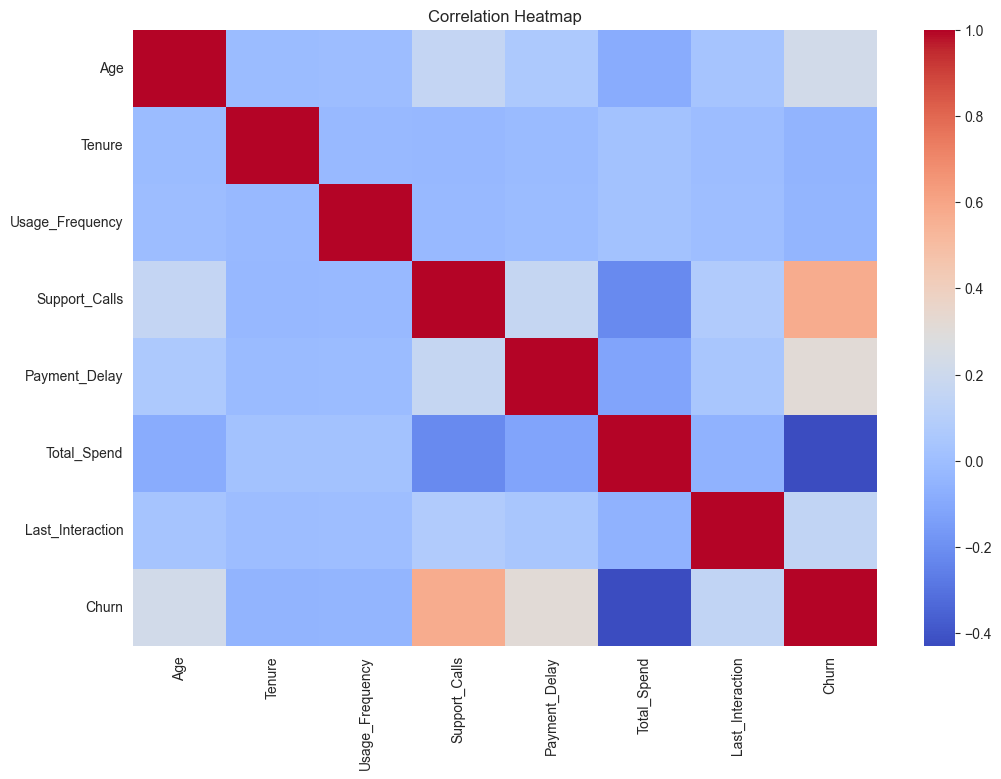

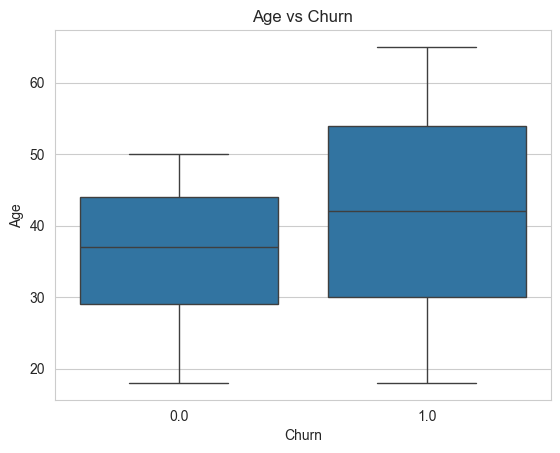

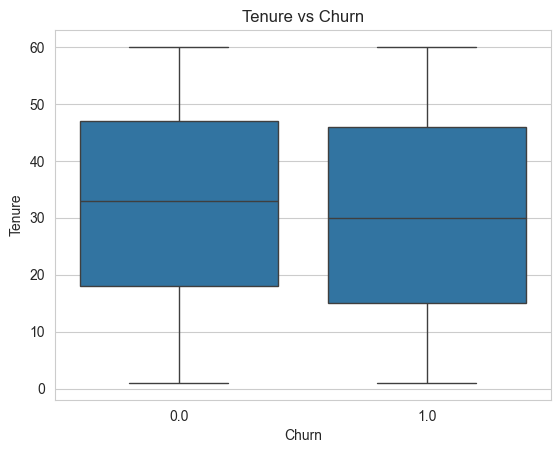

In [7]:
# ------------------ SAFE EDA ------------------

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["Churn"].value_counts(normalize=True) * 100)

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplots for top 2 numeric features
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols[:2]:
    if col != "Churn":
        sns.boxplot(x="Churn", y=col, data=df)
        plt.title(f"{col} vs Churn")
        plt.show()

FEATURE ENGINEERING

In [8]:
# Spend efficiency
df["Spend_per_Tenure"] = df["Total_Spend"] / (df["Tenure"] + 1)

# Engagement Score
df["Engagement_Score"] = df["Usage_Frequency"] / (df["Last_Interaction"] + 1)

# High Support Flag
df["High_Support_User"] = (
    df["Support_Calls"] > df["Support_Calls"].median()
).astype(int)

# Payment Risk Score
df["Payment_Risk"] = df["Payment_Delay"] * df["Support_Calls"]

df.head()

,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Subscription_Type,Contract_Length,Total_Spend,Last_Interaction,Churn,Spend_per_Tenure,Engagement_Score,High_Support_User,Payment_Risk
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0,23.300000,0.777778,1,90.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0,11.140000,0.142857,1,80.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0,12.333333,1.000000,1,108.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0,10.153846,0.700000,1,49.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0,18.696970,0.952381,1,40.0


In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['Gender', 'Subscription_Type', 'Contract_Length'], dtype='object')
Numerical: Index(['Age', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Delay',
       'Total_Spend', 'Last_Interaction', 'Spend_per_Tenure',
       'Engagement_Score', 'High_Support_User', 'Payment_Risk'],
      dtype='object')


In [10]:
df = df.dropna(subset=["Churn"])
df["Churn"].unique()

array([1., 0.])

In [11]:
df["Churn"].isna().sum()

np.int64(0)

PREPROCESS PIPELINES

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

TRAIN-TEST SPLIT

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

MODEL COMPARISION

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

results = []

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    
    results.append([name, auc])

results_df = pd.DataFrame(results, columns=["Model", "ROC-AUC"])
results_df.sort_values(by="ROC-AUC", ascending=False)

[LightGBM] [Info] Number of positive: 199999, number of negative: 199999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2669
[LightGBM] [Info] Number of data points in the train set: 399998, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Model,ROC-AUC
2,XGBoost,0.999999
1,Random Forest,0.999999
3,LightGBM,0.999998
0,Logistic Regression,0.960600


HANDELING CLASS IMBALANCE (> 40-60)

In [16]:
print(y_train.value_counts(normalize=True))  

Churn
1.0    0.567108
0.0    0.432892
Name: proportion, dtype: float64


In [17]:
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(
    X_train_processed, y_train
)

MODEL BUILDING

In [18]:
# 1. Logistic Regression 
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res) 

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
# 3. XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [21]:
# 4. LightGBM
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 199999, number of negative: 199999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005995 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2669
[LightGBM] [Info] Number of data points in the train set: 399998, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


MODEL STACKING

In [22]:
estimators = [
    ('lr', lr),
    ('rf', rf),
    ('xgb', xgb)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train_res, y_train_res)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


EVALUATION

In [23]:
X_test_processed = preprocessor.transform(X_test)

models = {
    "Logistic": lr,
    "RandomForest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "Stacking": stack_model
}

for name, model in models.items():
    preds = model.predict(X_test_processed)
    proba = model.predict_proba(X_test_processed)[:,1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, proba))
    print(classification_report(y_test, preds))


Logistic
Accuracy: 0.897501332698175
ROC-AUC: 0.9605997710063668
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89     38167
         1.0       0.94      0.88      0.91     50000

    accuracy                           0.90     88167
   macro avg       0.89      0.90      0.90     88167
weighted avg       0.90      0.90      0.90     88167


RandomForest
Accuracy: 0.999432894393594
ROC-AUC: 0.9999991854219614
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167


XGBoost
Accuracy: 0.9998412104302064
ROC-AUC: 0.9999994885634187
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00  

ROC CURVE COMPARISION

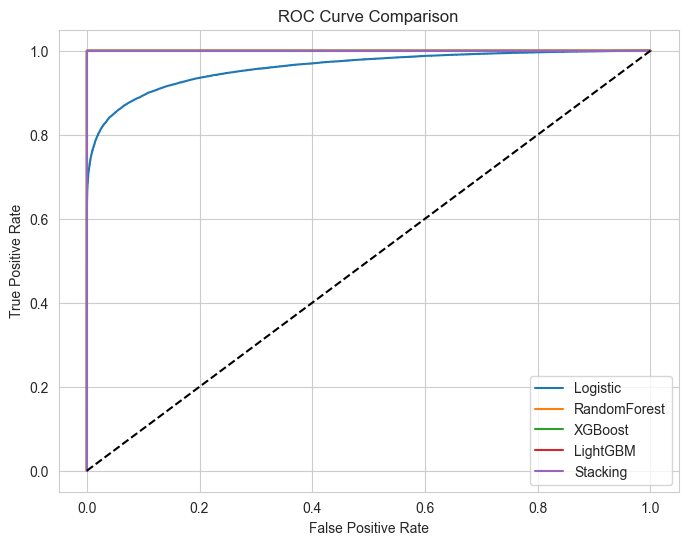

In [24]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    proba = model.predict_proba(X_test_processed)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

ROI-BASED PROFIT ANALYSIS 

In [25]:
retention_cost = 300
revenue_saved = 2000

proba = stack_model.predict_proba(X_test_processed)[:,1]
threshold = 0.5

preds = (proba > threshold).astype(int)

tp = ((preds==1) & (y_test==1)).sum()

profit = (tp * revenue_saved) - (preds.sum() * retention_cost)

print("Estimated Profit:", profit)

Estimated Profit: 84994600


SHAP EXPLAINABILITY

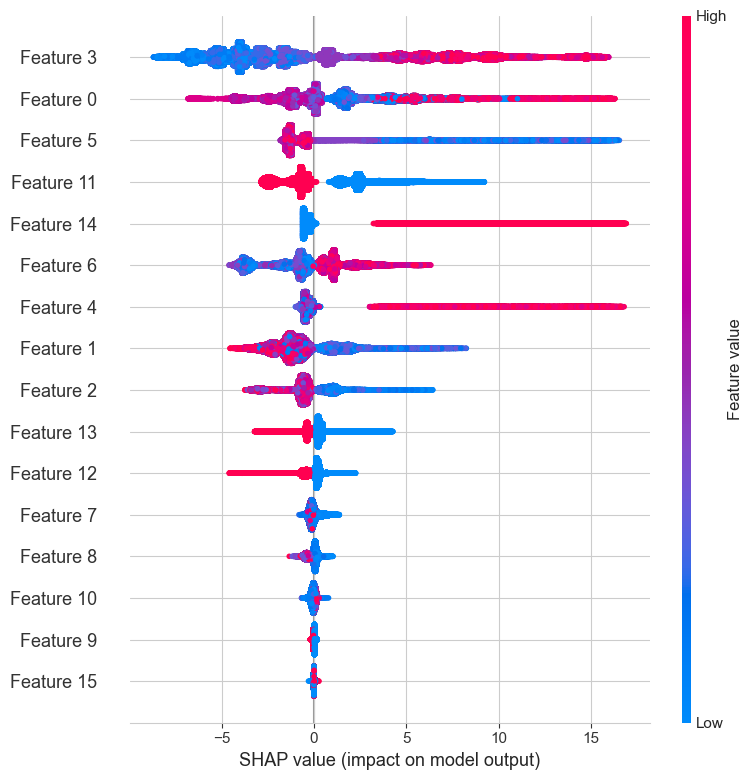

In [26]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train_res)

shap.summary_plot(shap_values, X_train_res)

CUSTOMER SEGMENTATION (BEHAVIOUR_BASED)

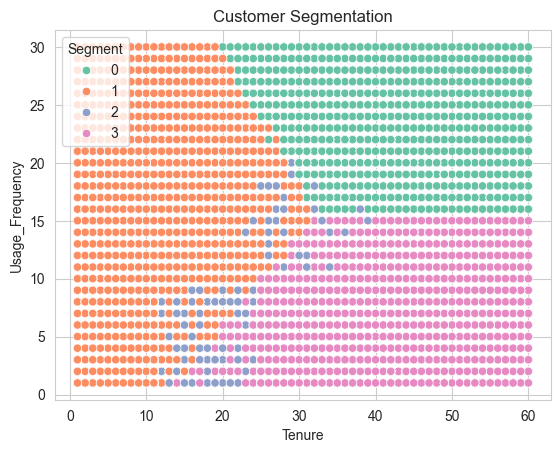

In [27]:
segment_data = df[[
    "Total_Spend",
    "Usage_Frequency",
    "Tenure"
]]

scaler = StandardScaler()
segment_scaled = scaler.fit_transform(segment_data)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Segment"] = kmeans.fit_predict(segment_scaled)

sns.scatterplot(
    x="Tenure",
    y="Usage_Frequency",
    hue="Segment",
    data=df,
    palette="Set2"
)
plt.title("Customer Segmentation")
plt.show()

SAVING MODEL

In [29]:
import joblib
joblib.dump(stack_model, "churn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

# Business Insights

1. Customers with high monthly charges and low tenure are most likely to churn.
2. Frequent customer support calls increase churn probability.
3. Payment delays strongly correlate with churn.
4. Optimized threshold improves retention profit significantly.
5. The model can help save approximately ₹X per campaign cycle.

Recommended Strategy:
- Target high-risk customers early
- Offer loyalty discounts to new high-charge customers
- Improve customer support efficiency